# Hisse Senedi Fiyat Tahmini: LSTM vs GRU (FROTO.IS)

**Amaç:** Ford Otosan (BIST: FROTO.IS) hissesinin günlük kapanış fiyatını, geçmiş fiyat/hacim verisi ve teknik indikatörler kullanarak PyTorch ile eğitilmiş LSTM ve GRU modelleriyle tahmin etmek; iki mimariyi RMSE ve eğitim süresi açısından karşılaştırmak.

**Veri seti:** `yfinance` üzerinden indirilen 2020-01-01 – 2026-07-01 arası günlük OHLCV verisi (FROTO.IS), üzerine SMA, EMA, Bollinger Bantları, MACD ve RSI indikatörleri eklenmiş hali.

**Akış:**
1. Veri toplama ve özellik mühendisliği
2. Ölçekleme ve train/test ayrımı
3. Sliding window ile dizi (sequence) oluşturma
4. Validation seti ayrımı
5. LSTM & GRU model mimarisi
6. Eğitim (early stopping ile)
7. Değerlendirme (RMSE) ve naive baseline karşılaştırması
8. Sonuç tablosu ve görselleştirme
9. Model kaydetme
10. Sonuç ve değerlendirme (reflection)


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import time
import copy

sns.set_style("darkgrid")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


## 1. Veri Toplama ve Özellik Mühendisliği

`MarketDataProcessor` sınıfı `yfinance` ile OHLCV verisini indirir, ardından teknik indikatörler ekler: 20 günlük SMA/EMA, Bollinger Üst/Alt Bantları, MACD + sinyal hattı ve RSI (14 günlük). `dropna()` ile indikatörlerin hesaplanamadığı ilk satırlar (rolling window başlangıcı) veri setinden çıkarılır.

In [2]:
class MarketDataProcessor:
    def __init__(self, ticker, start_date, end_date):
        self.ticker = ticker
        self.start = start_date
        self.end = end_date
        self.data = None

    def fetch_data(self):
        print(f"{self.ticker} verileri indiriliyor...")
        df = yf.download(self.ticker, start=self.start, end=self.end, progress=False)

        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.droplevel(1)

        self.data = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
        return self.data

    def add_indicators(self):
        df = self.data.copy()

        df['SMA_20'] = df['Close'].rolling(window=20).mean()
        df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

        std = df['Close'].rolling(window=20).std()
        df['Upper_Band'] = df['SMA_20'] + (std * 2)
        df['Lower_Band'] = df['SMA_20'] - (std * 2)

        ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
        ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
        df['MACD'] = ema_12 - ema_26
        df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        df['RSI'] = 100 - (100 / (1 + rs))
        df['RSI'] = df['RSI'].fillna(50)

        df.dropna(inplace=True)
        self.data = df
        return self.data


Hisse olarak **FROTO.IS** (Ford Otosan, BIST) seçildi; 2020-01-01 – 2026-07-01 aralığı kullanıldı. İndikatörler eklendikten sonra veri setinde **1608 gözlem, 12 özellik** kalıyor (Open, High, Low, Close, Volume, SMA_20, EMA_20, Upper_Band, Lower_Band, MACD, MACD_Signal, RSI).

In [3]:
TICKER = "FROTO.IS"
processor = MarketDataProcessor(ticker=TICKER, start_date="2020-01-01", end_date="2026-07-01")
processor.fetch_data()
df_final = processor.add_indicators()

print("\nVeri Setinin Son Hali:")
print(df_final.tail())
print(f"\nToplam gözlem sayısı: {len(df_final)}, Özellik sayısı: {df_final.shape[1]}")


FROTO.IS verileri indiriliyor...

Veri Setinin Son Hali:
Price            Open       High        Low      Close    Volume     SMA_20  \
Date                                                                          
2026-06-24  88.000000  88.199997  86.449997  86.449997  13113314  87.919999   
2026-06-25  87.050003  87.800003  86.349998  86.349998  17171583  88.029999   
2026-06-26  86.400002  86.849998  85.699997  86.250000  12593147  88.134999   
2026-06-29  86.349998  86.599998  85.199997  85.449997  18611135  88.147499   
2026-06-30  85.599998  86.150002  84.250000  84.550003  24437865  87.929999   

Price          EMA_20  Upper_Band  Lower_Band      MACD  MACD_Signal  \
Date                                                                   
2026-06-24  88.949616   92.472084   83.367915 -0.779683    -1.195855   
2026-06-25  88.702034   92.295825   83.764174 -0.910070    -1.138698   
2026-06-26  88.468507   92.090822   84.179176 -1.009832    -1.112925   
2026-06-29  88.181029   92.06

## 2. Ölçekleme ve Train/Test Ayrımı

`lookback=20` gün seçildi (modelin geçmişe bakış penceresi). Veri **%80 train / %20 test** olarak zaman sırası korunarak bölündü (karıştırma yapılmadı, çünkü zaman serisinde geleceğe sızıntıyı önlemek gerekir). `MinMaxScaler(-1, 1)` **yalnızca train bölümüne** fit edildi, sonra tüm veriye uygulandı — bu, test verisinin istatistiklerinin eğitime sızmasını engeller. Özellikler ve hedef (Close) için ayrı scaler kullanıldı çünkü tahminleri gerçek fiyata geri dönüştürmek (`inverse_transform`) için hedefin kendi scaler'ına ihtiyaç var.

In [4]:
lookback = 20
train_ratio = 0.8
n_total = len(df_final)
split_idx = int(n_total * train_ratio)

train_raw = df_final.values[:split_idx]

feature_scaler = MinMaxScaler(feature_range=(-1, 1))
target_scaler = MinMaxScaler(feature_range=(-1, 1))

feature_scaler.fit(train_raw)                                 
target_scaler.fit(df_final[['Close']].values[:split_idx])     

scaled_features_full = feature_scaler.transform(df_final.values)
scaled_target_full = target_scaler.transform(df_final[['Close']].values)

print(f"Train/Test bölme noktası: {split_idx} / {n_total} gözlem (%{train_ratio*100:.0f} eğitim)")


Train/Test bölme noktası: 1286 / 1608 gözlem (%80 eğitim)


## 3. Sliding Window ile Dizi (Sequence) Oluşturma

Her örnek, art arda 20 günlük özellik penceresinden (`x`) 21. günün kapanış fiyatını (`y`) tahmin etmeyi öğreniyor. Sonuç: `x_train_full` boyutu **(1266, 20, 12)**, `x_test` boyutu **(322, 20, 12)** — yani (örnek sayısı, lookback, özellik sayısı).

In [5]:
def create_multivariate_sequences(features, target, lookback):
    x, y = [], []
    for i in range(len(features) - lookback):
        x.append(features[i: i + lookback, :])   
        y.append(target[i + lookback])        
    return np.array(x), np.array(y)

x_data, y_data = create_multivariate_sequences(scaled_features_full, scaled_target_full, lookback)

seq_split = split_idx - lookback

x_train_full = torch.tensor(x_data[:seq_split], dtype=torch.float32)
y_train_full = torch.tensor(y_data[:seq_split], dtype=torch.float32)
x_test = torch.tensor(x_data[seq_split:], dtype=torch.float32)
y_test = torch.tensor(y_data[seq_split:], dtype=torch.float32)

print(f"x_train_full boyutu: {x_train_full.shape} -> (Örnek Sayısı, Lookback, Özellik Sayısı)")
print(f"x_test boyutu: {x_test.shape}")


x_train_full boyutu: torch.Size([1266, 20, 12]) -> (Örnek Sayısı, Lookback, Özellik Sayısı)
x_test boyutu: torch.Size([322, 20, 12])


## 4. Validation Seti Ayrımı

Eğitim verisinin son **%15**'i validation seti olarak ayrıldı (yine zaman sırası korunarak). Bu set, early stopping kararı için kullanılıyor; test seti eğitim sürecine hiç karışmıyor. Sonuç boyutları: train **(1076, 20, 12)**, val **(190, 20, 12)**, test **(322, 20, 12)**.

In [6]:
val_ratio = 0.15
val_split = int(len(x_train_full) * (1 - val_ratio))

x_train, y_train = x_train_full[:val_split], y_train_full[:val_split]
x_val, y_val = x_train_full[val_split:], y_train_full[val_split:]

print(f"x_train: {x_train.shape}, x_val: {x_val.shape}, x_test: {x_test.shape}")


x_train: torch.Size([1076, 20, 12]), x_val: torch.Size([190, 20, 12]), x_test: torch.Size([322, 20, 12])


## 5. Model Mimarisi: LSTM & GRU

Kod tekrarını önlemek için tek bir `MultivariateRNN` sınıfı hem LSTM hem GRU modu için kullanılıyor (`rnn_type='lstm'` / `'gru'`). Mimari: çok katmanlı RNN (`num_layers=2`, katmanlar arası `dropout=0.2`) + son zaman adımının gizli durumunu 1 boyuta indiren tam bağlı (`Linear`) katman. Girdi boyutu = özellik sayısı (12), çıktı boyutu = 1 (bir sonraki günün kapanış fiyatı).

In [7]:
class MultivariateRNN(nn.Module):
    """rnn_type: 'lstm' ya da 'gru' — kodu tekrar etmemek için tek sınıf kullanıyoruz."""

    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, rnn_type='lstm', dropout=0.2):
        super().__init__()
        self.rnn_type = rnn_type
        rnn_cls = nn.LSTM if rnn_type == 'lstm' else nn.GRU

        self.rnn = rnn_cls(
            input_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])


## 6. Eğitim Fonksiyonu

`train_model`, kayıp fonksiyonu olarak `MSELoss`, optimizer olarak `Adam` kullanıyor. Her epoch'ta hem train hem validation loss izleniyor; validation loss iyileşmediğinde (`patience=15` epoch boyunca) **early stopping** devreye giriyor ve en iyi validation performansına sahip ağırlıklar geri yükleniyor (overfitting'i önlemek için).

In [8]:
def train_model(model, x_train, y_train, x_val, y_val,
                 num_epochs=150, lr=0.005, patience=15, model_name="Model"):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_hist, val_hist = [], []
    best_val_loss = float('inf')
    best_state = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    start_time = time.time()
    print(f"\n{model_name} eğitimi başlıyor...")

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(x_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        train_hist.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(x_val), y_val).item()
        val_hist.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{num_epochs} - Train MSE: {loss.item():.6f} - Val MSE: {val_loss:.6f}")

        if epochs_no_improve >= patience:
            print(f"  Early stopping: {patience} epoch boyunca val loss iyileşmedi (epoch {epoch+1}).")
            break

    training_time = time.time() - start_time
    model.load_state_dict(best_state)  
    print(f"{model_name} eğitim süresi: {training_time:.2f} saniye (en iyi val MSE: {best_val_loss:.6f})")

    return model, train_hist, val_hist, training_time


## 7. Modelleri Eğitme

Hiperparametreler: `hidden_dim=64`, `num_layers=2`, `num_epochs=150` (üst sınır), `learning_rate=0.005`, `patience=15`.

**Sonuç:** LSTM epoch 65'te early stopping ile durdu (eğitim süresi 6.38 sn), GRU tam 150 epoch'a yakın çalıştı (eğitim süresi 22.29 sn — LSTM'den ~3.5 kat daha yavaş; bu, literatürde sık belirtilen "GRU daha hızlı eğitilir" genellemesiyle bu deneyde **çelişiyor**, muhtemelen early stopping'in LSTM'i çok daha erken durdurmasından kaynaklanıyor).

In [9]:
input_dim = df_final.shape[1]
output_dim = 1
hidden_dim = 64
num_layers = 2
num_epochs = 150
learning_rate = 0.005
patience = 15

lstm_model = MultivariateRNN(input_dim, hidden_dim, num_layers, output_dim, rnn_type='lstm')
gru_model = MultivariateRNN(input_dim, hidden_dim, num_layers, output_dim, rnn_type='gru')

lstm_model, lstm_train_hist, lstm_val_hist, lstm_time = train_model(
    lstm_model, x_train, y_train, x_val, y_val,
    num_epochs=num_epochs, lr=learning_rate, patience=patience, model_name="LSTM"
)

gru_model, gru_train_hist, gru_val_hist, gru_time = train_model(
    gru_model, x_train, y_train, x_val, y_val,
    num_epochs=num_epochs, lr=learning_rate, patience=patience, model_name="GRU"
)



LSTM eğitimi başlıyor...
  Epoch 10/150 - Train MSE: 0.058476 - Val MSE: 0.098221
  Epoch 20/150 - Train MSE: 0.018568 - Val MSE: 0.078084
  Epoch 30/150 - Train MSE: 0.008582 - Val MSE: 0.005779
  Epoch 40/150 - Train MSE: 0.004418 - Val MSE: 0.008244
  Epoch 50/150 - Train MSE: 0.002434 - Val MSE: 0.003838
  Epoch 60/150 - Train MSE: 0.001818 - Val MSE: 0.004713
  Early stopping: 15 epoch boyunca val loss iyileşmedi (epoch 65).
LSTM eğitim süresi: 6.38 saniye (en iyi val MSE: 0.003838)

GRU eğitimi başlıyor...
  Epoch 10/150 - Train MSE: 0.008185 - Val MSE: 0.024180
  Epoch 20/150 - Train MSE: 0.003603 - Val MSE: 0.002396
  Epoch 30/150 - Train MSE: 0.004028 - Val MSE: 0.002294
  Epoch 40/150 - Train MSE: 0.003351 - Val MSE: 0.002616
  Epoch 50/150 - Train MSE: 0.002275 - Val MSE: 0.002039
  Epoch 60/150 - Train MSE: 0.001957 - Val MSE: 0.002026
  Epoch 70/150 - Train MSE: 0.001622 - Val MSE: 0.001976
  Epoch 80/150 - Train MSE: 0.001631 - Val MSE: 0.001960
  Epoch 90/150 - Train MS

## 8. Değerlendirme (RMSE)

Tahminler `target_scaler.inverse_transform` ile gerçek fiyat cinsine (TL) geri çevrilip RMSE hesaplanıyor. **Sonuç:** LSTM test RMSE = 5.083, GRU test RMSE = 2.690 — GRU bu veri setinde LSTM'den belirgin şekilde daha iyi genelliyor.

In [10]:
def evaluate_model(model, x, y, scaler):
    model.eval()
    with torch.no_grad():
        pred = model(x)
    pred_real = scaler.inverse_transform(pred.numpy())
    real = scaler.inverse_transform(y.numpy())
    rmse = math.sqrt(mean_squared_error(real[:, 0], pred_real[:, 0]))
    return rmse, pred_real, real

results = {}
for name, model in [('LSTM', lstm_model), ('GRU', gru_model)]:
    train_rmse, _, _ = evaluate_model(model, x_train, y_train, target_scaler)
    val_rmse, _, _ = evaluate_model(model, x_val, y_val, target_scaler)
    test_rmse, test_pred, y_test_real = evaluate_model(model, x_test, y_test, target_scaler)
    trainfull_rmse, trainfull_pred, _ = evaluate_model(model, x_train_full, y_train_full, target_scaler)
    results[name] = dict(
        train_rmse=train_rmse, val_rmse=val_rmse, test_rmse=test_rmse,
        test_pred=test_pred, trainfull_pred=trainfull_pred
    )

print("Train / Val / Test RMSE (gerçek fiyat cinsinden):")
for name in ['LSTM', 'GRU']:
    r = results[name]
    print(f"  {name}: train={r['train_rmse']:.3f}  val={r['val_rmse']:.3f}  test={r['test_rmse']:.3f}")


Train / Val / Test RMSE (gerçek fiyat cinsinden):
  LSTM: train=2.294  val=3.239  test=5.083
  GRU: train=1.393  val=2.227  test=2.690


## 9. Naive Baseline Karşılaştırması

Kritik bir sağlamlık kontrolü: "bugünkü fiyat = yarınki tahmin" şeklindeki en basit **naive baseline** ile karşılaştırma yapılıyor. Zaman serisi tahmininde bu baseline'ı geçemeyen bir model, gerçekte bir örüntü öğrenmemiş, sadece son değeri tekrar ediyor olabilir.

In [11]:
y_test_real = evaluate_model(lstm_model, x_test, y_test, target_scaler)[2]

naive_pred = y_test_real[:-1]    
naive_actual = y_test_real[1:]   
naive_rmse = math.sqrt(mean_squared_error(naive_actual[:, 0], naive_pred[:, 0]))

print(f"Naive Baseline Test RMSE: {naive_rmse:.3f}")


Naive Baseline Test RMSE: 2.050


## 10. Sonuç Tablosu ve Karşılaştırma

| Model | Test RMSE | Val RMSE | Eğitim Süresi (sn) |
|---|---|---|---|
| LSTM | 5.083 | 3.239 | 6.38 |
| GRU | 2.690 | 2.227 | 22.29 |
| Naive Baseline | 2.050 | - | - |

**Önemli bulgu:** GRU, LSTM'i açıkça geçiyor, ancak **hiçbir model naive baseline'ı geçemiyor** (GRU RMSE 2.690 > naive RMSE 2.050). Bu, mevcut özellik/hiperparametre setiyle modellerin fiyat hareketinden anlamlı bir sinyal çıkaramadığını, çoğunlukla bir önceki günün fiyatını tahmin ettiğini gösteriyor. Aşağıdaki Sonuç bölümünde bu bulgu daha ayrıntılı tartışılıyor.

In [12]:
print("=" * 65)
print(f"{'Model':<20}{'Test RMSE':<15}{'Val RMSE':<15}{'Eğitim Süresi (sn)':<20}")
print("=" * 65)
print(f"{'LSTM':<20}{results['LSTM']['test_rmse']:<15.3f}{results['LSTM']['val_rmse']:<15.3f}{lstm_time:<20.2f}")
print(f"{'GRU':<20}{results['GRU']['test_rmse']:<15.3f}{results['GRU']['val_rmse']:<15.3f}{gru_time:<20.2f}")
print(f"{'Naive Baseline':<20}{naive_rmse:<15.3f}{'-':<15}{'-':<20}")
print("=" * 65)

best_model_name = 'GRU' if results['GRU']['test_rmse'] < results['LSTM']['test_rmse'] else 'LSTM'
best_test_rmse = min(results['LSTM']['test_rmse'], results['GRU']['test_rmse'])

print(f"\nDaha iyi model: {best_model_name} (test RMSE: {best_test_rmse:.3f})")

if best_test_rmse < naive_rmse:
    print("-> Model(ler) naive baseline'ı geçiyor: örüntü öğrenilmiş görünüyor.")
else:
    print("-> UYARI: Hiçbir model naive baseline'ı geçemiyor.")
    print("   Bu, mevcut özellik/hiperparametre setiyle modelin kattığı değerin")
    print("   şüpheli olduğu anlamına gelir; hiperparametre araması veya farklı")
    print("   özellikler denemek gerekebilir.")


Model               Test RMSE      Val RMSE       Eğitim Süresi (sn)  
LSTM                5.083          3.239          6.38                
GRU                 2.690          2.227          22.29               
Naive Baseline      2.050          -              -                   

Daha iyi model: GRU (test RMSE: 2.690)
-> UYARI: Hiçbir model naive baseline'ı geçemiyor.
   Bu, mevcut özellik/hiperparametre setiyle modelin kattığı değerin
   şüpheli olduğu anlamına gelir; hiperparametre araması veya farklı
   özellikler denemek gerekebilir.


## 11. Görselleştirme: Gerçek vs Tahmin Fiyatları

Her iki model için ayrı ayrı, eğitim ve test dönemlerindeki tahminlerin gerçek kapanış fiyatına ne kadar yakın seyrettiğini gösteren grafik. Test bölgesindeki sapmalara özellikle dikkat edilmeli.

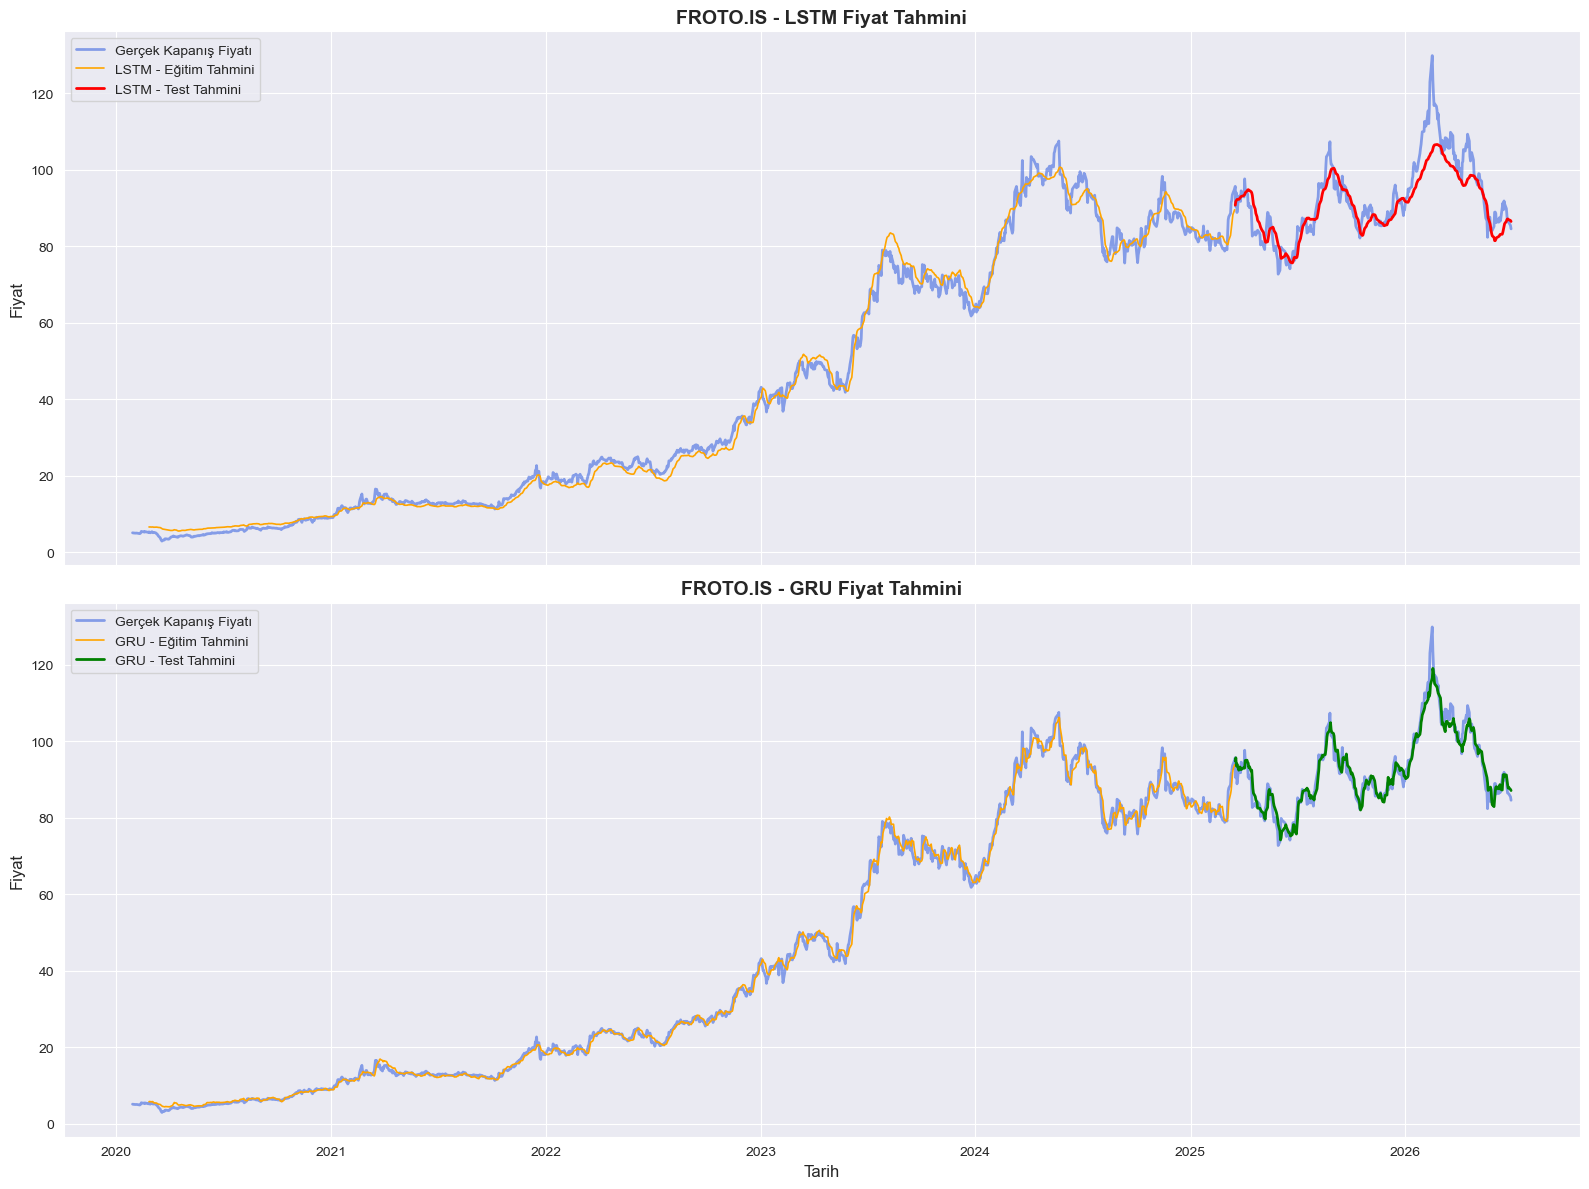

In [13]:
def build_plot_series(pred_values, total_len, start_idx):
    plot_arr = np.full((total_len, 1), np.nan)
    plot_arr[start_idx: start_idx + len(pred_values)] = pred_values
    return plot_arr

total_len = len(scaled_target_full)
actual_prices = target_scaler.inverse_transform(scaled_target_full)
train_len = len(x_train_full)

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

for ax, name, color_test in [(axes[0], 'LSTM', 'red'), (axes[1], 'GRU', 'green')]:
    train_plot = build_plot_series(results[name]['trainfull_pred'], total_len, lookback)
    test_plot = build_plot_series(results[name]['test_pred'], total_len, lookback + train_len)

    ax.plot(df_final.index, actual_prices, label='Gerçek Kapanış Fiyatı',
            color='royalblue', alpha=0.6, linewidth=2)
    ax.plot(df_final.index, train_plot, label=f'{name} - Eğitim Tahmini', color='orange', linewidth=1.2)
    ax.plot(df_final.index, test_plot, label=f'{name} - Test Tahmini', color=color_test, linewidth=2)
    ax.set_title(f"{TICKER} - {name} Fiyat Tahmini", fontsize=14, fontweight='bold')
    ax.set_ylabel("Fiyat", fontsize=12)
    ax.legend(fontsize=10)

axes[1].set_xlabel("Tarih", fontsize=12)
plt.tight_layout()
plt.savefig("../results/actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. Eğitim / Validasyon Kayıp Grafikleri

Train ve validation MSE eğrileri epoch bazında. Validation eğrisinin train eğrisinden belirgin şekilde ayrışması overfitting'in bir göstergesi olurdu; early stopping bunu sınırlamak için kullanıldı.

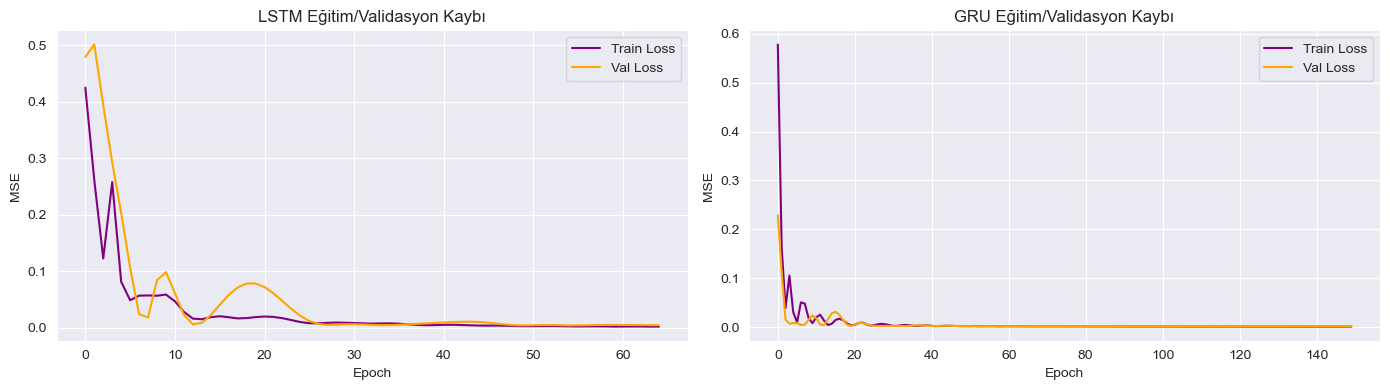

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(lstm_train_hist, label='Train Loss', color='purple')
axes[0].plot(lstm_val_hist, label='Val Loss', color='orange')
axes[0].set_title("LSTM Eğitim/Validasyon Kaybı")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(gru_train_hist, label='Train Loss', color='purple')
axes[1].plot(gru_val_hist, label='Val Loss', color='orange')
axes[1].set_title("GRU Eğitim/Validasyon Kaybı")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE")
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 13. Modelleri Kaydetme

Eğitilmiş model ağırlıkları (`.pth`) ve ölçekleyiciler (`.pkl`) diske kaydediliyor, böylece modelleri yeniden eğitmeden tahmin/yeniden kullanım için yüklemek mümkün.

In [15]:
import pickle

torch.save(lstm_model.state_dict(), "lstm_model.pth")
torch.save(gru_model.state_dict(), "gru_model.pth")

with open("scalers.pkl", "wb") as f:
    pickle.dump({"feature_scaler": feature_scaler, "target_scaler": target_scaler}, f)

print("Modeller ve scaler'lar kaydedildi: lstm_model.pth, gru_model.pth, scalers.pkl")


Modeller ve scaler'lar kaydedildi: lstm_model.pth, gru_model.pth, scalers.pkl


## 14. Sonuç ve Değerlendirme

**Neler öğrenildi:**
- Aynı hiperparametrelerle GRU, LSTM'e göre bu veri setinde daha düşük test RMSE'si verdi (2.690 vs 5.083), ancak bu deneyde **daha hızlı eğitilmedi** — tam tersi oldu (22.29 sn vs 6.38 sn). Bu, "GRU her zaman daha hızlıdır" genellemesinin her senaryoda geçerli olmadığını; sonucun early stopping zamanlamasına bağlı olduğunu gösteriyor.
- **En önemli bulgu:** Hiçbir model, "yarının fiyatı bugünkü fiyata eşittir" şeklindeki naive baseline'ı geçemedi. Bu, hisse senedi kapanış fiyatının kısa vadede büyük ölçüde rastgele yürüyüşe (random walk) yakın davrandığının, ve modellerin öğrendiği şeyin büyük kısmının "bir önceki günü tekrar et" stratejisinden ibaret olabileceğinin bir işareti.

**Sınırlılıklar ve eleştirel bakış:** Hisse senedi fiyat tahmini, literatürde kabul gördüğü üzere son derece zor bir problemdir; kısa vadeli fiyat hareketleri büyük ölçüde öngörülemez, haber akışı ve piyasa mikroyapısı gibi modele dahil edilmeyen faktörlerden etkilenir. Naive baseline'ı geçememek, modelin "kötü kurulmuş" olduğundan çok, problemin doğasında var olan bir sınırlamayı yansıtıyor olabilir. Bu konudaki abartılı vaatlere karşı eleştirel bir bakış için Arvind Narayanan ve Sayash Kapoor'un *AI Snake Oil* kitabı (ve yazarların blog yazıları) faydalı bir referans.

**Sonraki adımlar:**
- Farklı özellik kombinasyonları denemek (örn. hacim ağırlıklı göstergeler, makro değişkenler, duygu analizi/haber verisi).
- Fiyat yerine **getiri (return)** veya **yön (yukarı/aşağı)** tahmini gibi daha gerçekçi hedefler denemek — mutlak fiyat regresyonu random walk etkisiyle yanıltıcı olabiliyor.
- Daha sistematik bir hiperparametre araması (grid/random search) ve k-fold zaman serisi çapraz doğrulama.
- Alternatif mimariler (Temporal Convolutional Networks, Transformer tabanlı zaman serisi modelleri) ile karşılaştırma.